In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import sys
sys.path.append('../utils')
from functions import * 

In [3]:
# load adata object for tabula muris 
adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TS_figshare/TabulaSapiens.h5ad")

In [4]:
adata.obs 

,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender
AAACCCACACTCCTGT_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,7633.0,2259,macrophage,Monocyte/Macrophage,True,immune,male
AAACGAAGTACCAGAG_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,2858.0,1152,monocyte,Monocyte,True,immune,male
AAACGCTCAACGGCTC_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,7787.0,2983,endothelial cell of hepatic sinusoid,Endothelial,True,endothelial,male
AAAGAACAGCCTCTTC_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,10395.0,2598,macrophage,Monocyte/Macrophage,True,immune,male
AAAGAACGTAGCACAG_TSP6_Liver_NA_10X_1_1,Liver,10X,TSP6,nan,6610.0,2125,liver dendritic cell,Dendritic cell,True,immune,male
...,...,...,...,...,...,...,...,...,...,...,...
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P4_S364,Vasculature,smartseq2,TSP2,aorta,13205.0,579,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P5_S365,Vasculature,smartseq2,TSP2,aorta,9565.0,529,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P7_S367,Vasculature,smartseq2,TSP2,aorta,195639.0,2753,endothelial cell,endothelial cell,True,endothelial,female
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_P8_S368,Vasculature,smartseq2,TSP2,aorta,37260.0,984,endothelial cell,endothelial cell,True,endothelial,female


In [5]:
adata.obs.method.unique()

['10X', 'smartseq2']
Categories (2, object): ['10X', 'smartseq2']

In [6]:
ss2 = adata.obs[adata.obs["method"] == "smartseq2"]
print(ss2.shape)
# summarize number of ss2 files per donor 
ss2.groupby("donor").size()

(27051, 11)


donor
TSP1     3838
TSP2     9894
TSP3      284
TSP4     3297
TSP5      133
TSP6      568
TSP7     4979
TSP8      633
TSP9       83
TSP10    1495
TSP11    1032
TSP12     277
TSP13     538
TSP14       0
TSP15       0
dtype: int64

In [7]:
ss2.groupby("organ_tissue").size().sort_values(ascending=False)

organ_tissue
Muscle             5043
Lymph_Node         2384
Bone_Marrow        2290
Spleen             2148
Blood              1977
Lung               1590
Tongue             1391
Bladder            1161
Pancreas            996
Vasculature         847
Skin                844
Salivary_Gland      832
Fat                 651
Prostate            633
Small_Intestine     606
Thymus              599
Mammary             580
Trachea             474
Large_Intestine     442
Eye                 417
Kidney              370
Uterus              286
Heart               277
Liver               213
dtype: int64

In [8]:
# filter adata object to just ss2 data and muscle tissue 
adata = adata[adata.obs["method"] == "smartseq2"]
adata = adata[adata.obs["organ_tissue"] == "Muscle"]
print(adata.shape)

(5043, 58870)


In [18]:
adata = adata[~adata.obs["free_annotation"].isin(["endothelial cell of artery", "erythrocyte", "mesothelial cell"]), :]       
print(adata.shape)       

(5037, 58870)


/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


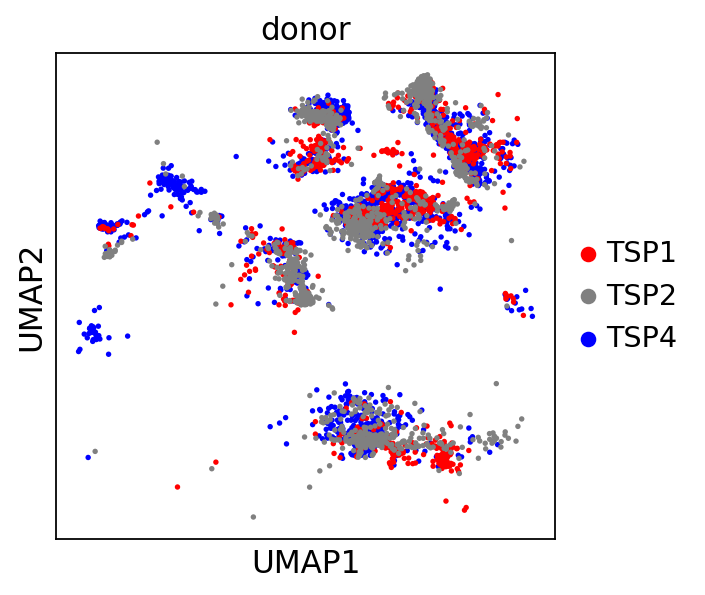

In [19]:
# use values in adata.obsm to plot the UMAP
sc.pl.umap(adata, color=["donor"], palette=["red", "grey", "blue"])

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


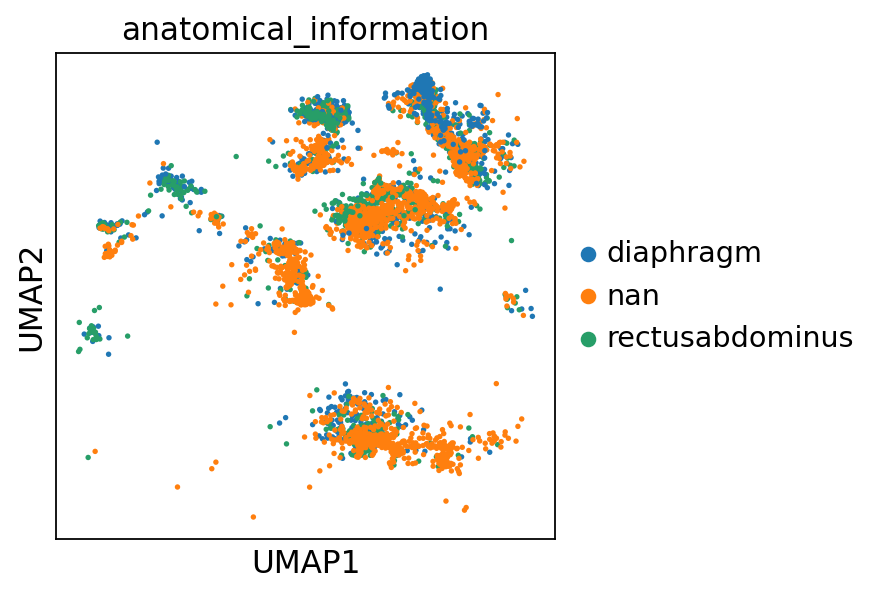

In [20]:
sc.pl.umap(adata, color=["anatomical_information"])

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


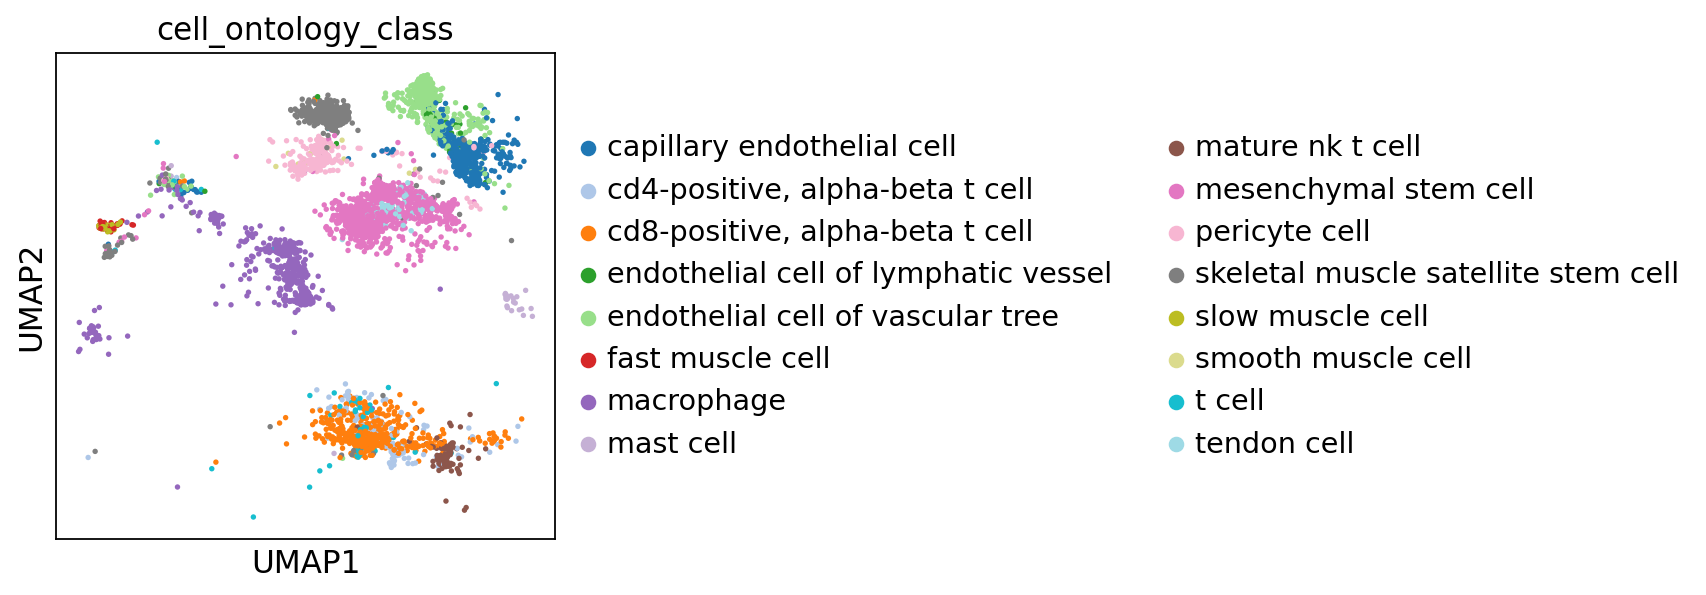

In [21]:
sc.pl.umap(adata, color = "cell_ontology_class", palette = "tab20")

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


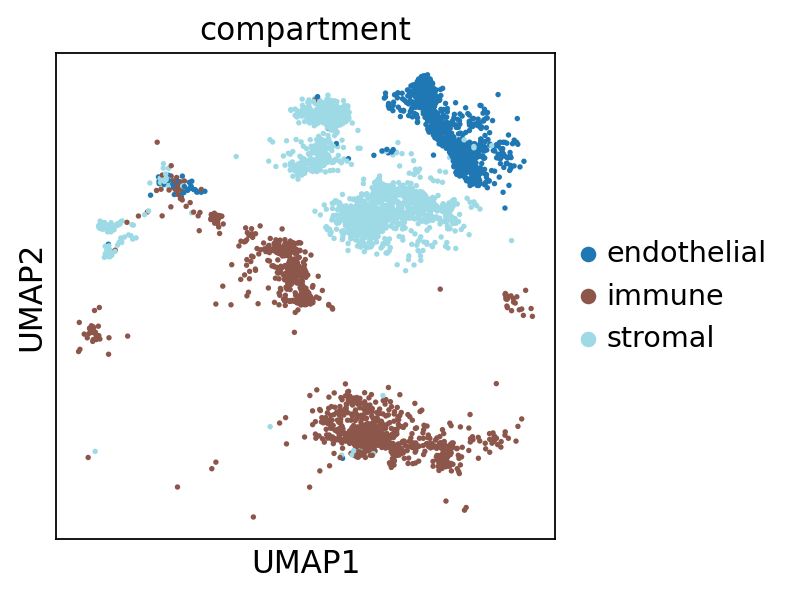

In [33]:
sc.pl.umap(adata, color = "compartment")

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


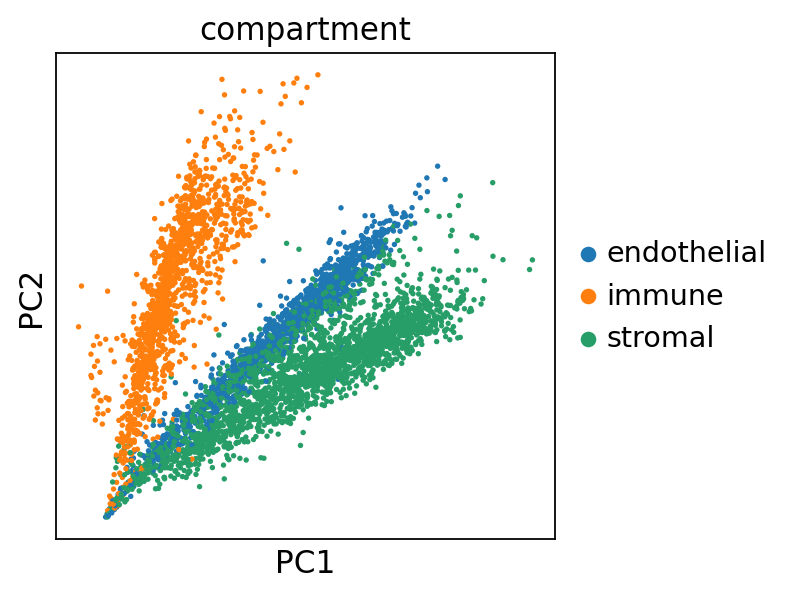

In [25]:
sc.pl.pca(adata, color='compartment')

In [29]:
adata.obs.groupby(["cell_ontology_class", "compartment"]).size().sort_values(ascending=False)

cell_ontology_class                   compartment
mesenchymal stem cell                 stromal        1423
endothelial cell of vascular tree     endothelial     735
skeletal muscle satellite stem cell   stromal         611
macrophage                            immune          508
cd8-positive, alpha-beta t cell       immune          488
capillary endothelial cell            endothelial     418
pericyte cell                         stromal         284
cd4-positive, alpha-beta t cell       immune          142
mature nk t cell                      immune           93
endothelial cell of lymphatic vessel  endothelial      66
fast muscle cell                      stromal          65
tendon cell                           stromal          55
t cell                                immune           53
slow muscle cell                      stromal          52
mast cell                             immune           29
smooth muscle cell                    stromal          15
endothelial cell of ly

In [ ]:
# sumamrize number of samples across donors and organs and filter out zero entries 
donors_summ = ss2.groupby(["donor", "organ_tissue"]).size().unstack().fillna(0)
# remove rows that have all zeros
donors_summ = donors_summ.loc[(donors_summ != 0).any(axis=1)]

In [ ]:
ss2["bam_file_name"] = ss2.index

In [ ]:
# Assuming 'ss2' is your DataFrame
ss2.loc[ss2["donor"] == "TSP1", "donor_id"] = "Pilot1"
ss2.loc[ss2["donor"] == "TSP2", "donor_id"] = "Pilot2"
ss2.loc[ss2["donor"] == "TSP3", "donor_id"] = "Pilot3"
ss2.loc[ss2["donor"] == "TSP4", "donor_id"] = "Pilot4"
ss2.loc[ss2["donor"] == "TSP5", "donor_id"] = "Pilot5"
ss2.loc[ss2["donor"] == "TSP6", "donor_id"] = "Pilot6"
ss2.loc[ss2["donor"] == "TSP7", "donor_id"] = "Pilot7"
ss2.loc[ss2["donor"] == "TSP8", "donor_id"] = "Pilot8"
ss2.loc[ss2["donor"] == "TSP9", "donor_id"] = "Pilot9"
ss2.loc[ss2["donor"] == "TSP10", "donor_id"] = "Pilot10"
ss2.loc[ss2["donor"] == "TSP11", "donor_id"] = "Pilot11"
ss2.loc[ss2["donor"] == "TSP12", "donor_id"] = "Pilot12"
ss2.loc[ss2["donor"] == "TSP13", "donor_id"] = "Pilot13"
ss2.loc[ss2["donor"] == "TSP14", "donor_id"] = "Pilot14"
ss2.loc[ss2["donor"] == "TSP15", "donor_id"] = "Pilot15"

In [ ]:
ss2[ss2["bam_file_name"] == "TSP2_LymphNode_Inguinal_SS2_B113694_B133052_ImmuneLinNeg_I10_S202"]

In [ ]:
ss2[ss2["organ_tissue"] == "Muscle"].donor.unique()

In [ ]:
# write SS2 to file saved as "tabula_sapiens_ss2_metadata.csv"
ss2.to_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/tabula_sapiens_ss2_metadata.csv", index=False)

In [ ]:
ss2[ss2["donor"] == "TSP1"]

In [ ]:
for org in ss2.organ_tissue.unique():
    print(org)

In [ ]:
# save ss2 file as text file for saving BAM files 
ss2_short = ss2[["donor", "organ_tissue", "bam_file_name", "donor_id"]]
print(ss2_short.head())
ss2_short.to_csv("/commons/projects/CZI-tabula-sapiens/SS2_data_processing/ss2_samples.txt", sep="\t", index=False, header=False)

In [ ]:
ss2

In [ ]:
# subset adata to just the cells in ss2 
adata.obsm["X_umap"]

# turn adata.obsm["X_umap"] into dataframe 
umap = pd.DataFrame(adata.obsm["X_umap"])
umap["cell_id"] = adata.obs.index
umap.head()

In [ ]:
umap = umap[umap.cell_id.isin(ss2.index)]
umap.head()

In [ ]:
LN = ss2[ss2["organ_tissue"] == "Muscle"]
umap = umap[umap.cell_id.isin(LN.index)]
umap.head()

In [ ]:
# change umap columns to UMAP1, UMAP2
umap.columns = ['UMAP1', 'UMAP2', 'cell_id']

In [ ]:
ss2["cell_id"] = ss2.index 
# merge ss2 and umap 
umap = ss2.merge(umap)

In [ ]:
# assign unique colors to free_annotation column and use those to make scatterplot
annotations = umap['free_annotation'].unique()

# Then we generate a list of colors for these labels.
colors = plt.cm.tab20(np.linspace(0, 1, len(annotations)))

# Now we create a dictionary that maps annotations to colors.
annotation_to_color = dict(zip(annotations, colors))

# We apply this mapping to the 'free_annotation' column to get the actual color values.
umap['color'] = umap['free_annotation'].map(annotation_to_color)

umap

In [ ]:
umap.cell_ontology_class.value_counts().head(20)

In [ ]:
# Create a list of patches to use as handles in the legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=annotation_to_color[annotation], label=annotation) for annotation in annotations]

# plt scatter plot of umap1 vs umap2 and color by free_annotation
plt.figure(figsize=(7,7))
plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)
plt.title("Lymph Node")
plt.show()

In [ ]:
plt.scatter(umap["UMAP1"], umap["UMAP2"], c=umap["color"], cmap="tab20", alpha=0.5)

In [ ]:
# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [ ]:
plt.legend(handles=legend_handles, title='Annotations')


In [ ]:
adata

In [ ]:
# subset adata to just the cells in ss2 and muscle organ 
adata = adata[adata.obs.index.isin(ss2.index)]
adata = adata[adata.obs.index.isin(LN.index)]
adata

In [ ]:
sc.pl.highest_expr_genes(adata, n_top=20, )

In [ ]:
sc.pp.filter_cells(adata, min_genes=200) # remove cells that have less than 200 genes expressed
sc.pp.filter_genes(adata, min_cells=5) # remove genes that are expressed in less than 3 cells
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
# remove cells that have more than 5% mitochondrial genes
adata

In [ ]:
# With pp.calculate_qc_metrics, we can compute many metrics very efficiently.
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)

In [ ]:
print("Remove cells with very high values for total_counts, possible doublets")

print('Started with: \n', adata)
print_separator()
adata = adata[adata.obs.total_counts < 10000, :]
print('Finished with: \n', adata)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

#sc.pl.highly_variable_genes(adata)

adata.raw = adata
adata = adata[:, adata.var.highly_variable]

#Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. Scale the data to unit variance.
sc.pp.regress_out(adata, ['total_counts'])

#Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

In [ ]:
adata.obs.head()

In [ ]:
# remove these cell types from adata: endothelial cell of artery, erythrocyte, mesothelial cell             
adata = adata[~adata.obs["free_annotation"].isin(["endothelial cell of artery", "erythrocyte", "mesothelial cell"]), :]              

In [ ]:
print("The number of cells and genes going into PCA is: " + str(adata.shape))
sc.tl.pca(adata, svd_solver='arpack')

In [ ]:
sc.pl.pca(adata, color='cell_ontology_class')

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata)

In [ ]:
sc.pl.umap(adata, color=['leiden'])

In [ ]:
sc.pl.umap(adata, color=['cell_ontology_class'])

In [ ]:
# plot adata umap color by TSP by donor
# use colors grey, blue and red for TSP1, TSP2, TSP4
sc.pl.umap(adata, color=['donor'], palette=["grey", "blue", "red"])

In [ ]:
sc.pl.umap(adata, color=['anatomical_information'])

In [ ]:
# calculate total counts per cell across each donor 
adata.obs.groupby("donor").total_counts.sum()

In [ ]:
adata.obs